# **Dados de Clima-Tempo**
### FMV - Limpeza e tratamento de Dados

#### Contextualização

O conjunto de dados a ser analisado trata-se de uma séries de dias registrados por jogadores de determinado esporte. Estes analisaram as condições ambientais e climáticas de cada dia, decidindo se deveriam jogar ou não.

Todavia, há dados incompletos nos registros. Estes devendo ser tratados e limpos para análises mais profundas.

A faixa de temperatura habitável na Terra geralmente varia entre 32°F e 122°F, ou seja, entre 0°C e 50°C.
- Conforto térmico humano: entre 68°F e 77°F (20°C a 25°C).

A umidade relativa do ar na Terra representa a quantidade de vapor d’água presente na atmosfera em relação ao máximo que ela pode conter a uma determinada temperatura. Ela varia amplamente conforme o clima, a altitude e a proximidade de corpos d’água. Ou seja, sua faixa de valor varia entre 0 a 100 %.
-  A umidade é essencial para a formação de nuvens e precipitação. Quando o ar atinge 100% de umidade relativa, ele está saturado e pode ocorrer condensação (chuva, neblina, etc.).

#### Importação

Importação das bibliotecas utilizadas

In [71]:
import pandas as pd
import seaborn as sns
import statistics  as sts

Importação dos dados utilizados

In [72]:
dataset = pd.read_csv("tempo.csv", sep=";")
dataset.head()

,Aparencia,Temperatura,Umidade,Vento,Jogar
0,sol,85,85.0,FALSO,nao
1,sol,80,90.0,VERDADEIRO,nao
2,nublado,83,86.0,FALSO,sim
3,chuva,70,NaN,FALSO,sim
4,chuva,68,80.0,FALSO,sim


In [73]:
dataset.shape

(14, 5)

Os dados apresentam 14 linhas e 5 colunas.

In [74]:
dataset.isnull().sum()

Aparencia      0
Temperatura    0
Umidade        1
Vento          1
Jogar          0
dtype: int64

Foram encontrados valores nulos:
- Umidade: 01
- Vento: 01

#### Análise exploratória dos dados

##### Aparência

Este dataset condiz com a aparência do céu encontrada nos dias registrados.

In [75]:
join = dataset.groupby(["Aparencia"]).size()
join

Aparencia
chuva      5
menos      1
nublado    3
sol        5
dtype: int64

Possui valor inválido.
- "menos"

<Axes: ylabel='Aparencia'>

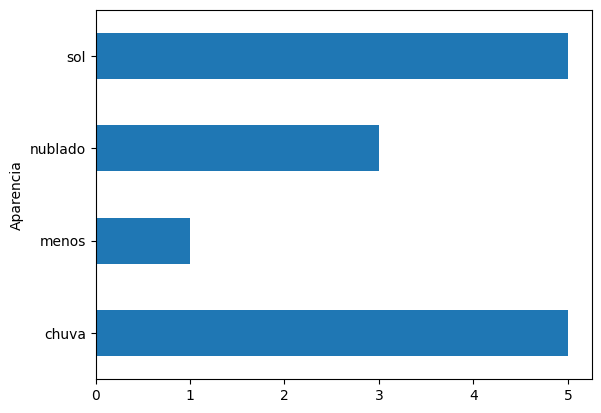

In [76]:
join.plot.barh(x="Aparencia", y="Frequencia")

In [77]:
mode = dataset['Aparencia'].mode()[0]
f"Moda da Aparência: {mode}"

'Moda da Aparência: chuva'

A moda encontrada foi "chuva".

In [78]:
dataset['Aparencia'].isnull().sum()

np.int64(0)

Nenhum valor nulo.

##### Temperatura (°F)

Este dataset condiz com a temperatura do ambiente em fahrenheit encontrada nos dias registrados.

In [79]:
join = dataset["Temperatura"]
join.describe()

count      14.000000
mean      155.571429
std       306.433759
min        64.000000
25%        69.250000
50%        73.500000
75%        80.750000
max      1220.000000
Name: Temperatura, dtype: float64

É possível encontrar valores obtusos entre os dados.
- Avaliar possíveis outliers

Text(0.5, 1.0, 'Temperatura (°F)')

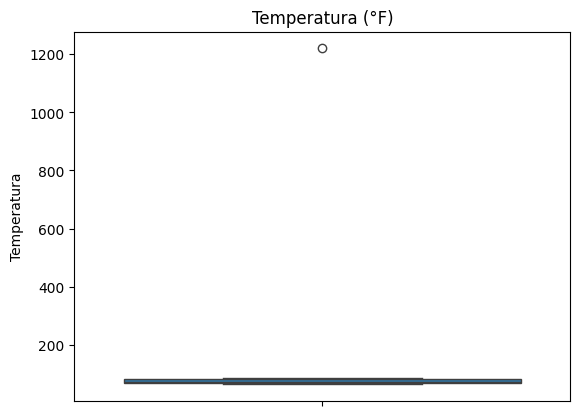

In [80]:
sns.boxplot(join).set_title('Temperatura (°F)')

Text(0.5, 1.0, 'Temperatura (°F)')

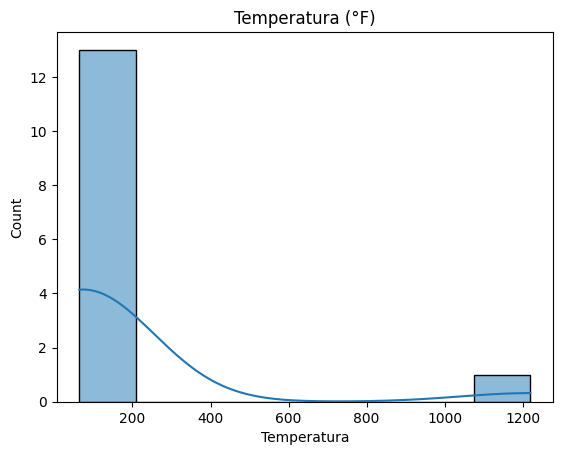

In [81]:
sns.histplot(join, kde=True).set_title('Temperatura (°F)')

Os gráficos apresentam apenas um valor distorcendo o conjunto de dados. Pelo contexto dos dados, este valor não deveria estar presente.

In [82]:
mean = round(sts.mean(join), 2)
f"Média da Temperatura: {mean} °F."

'Média da Temperatura: 155.57 °F.'

Sendo assim, a média também é levemente distorcida.

In [83]:
median = round(sts.median(join), 2)
f"Mediana da Temperatura: {median} °F."

'Mediana da Temperatura: 73.5 °F.'

Entretanto, percebe-se uma concentração de dados. Visto que a mediana é de 73.5 °F.

In [84]:
std = round(sts.stdev(join), 2)
f"Desvio Padrão da Temperatura: {std} °F."

'Desvio Padrão da Temperatura: 306.43 °F.'

Desvio padrão também encontra-se distorcido.

In [85]:
dataset['Temperatura'].isnull().sum()

np.int64(0)

Nenhum valor nulo encontrado.

##### Umidade (%)

Este dataset condiz com a umidade relativa do ambiente encontrada nos dias registrados.

In [86]:
join = dataset["Umidade"]
join.describe()

count     13.000000
mean      89.769231
std       34.540203
min       65.000000
25%       70.000000
50%       85.000000
75%       90.000000
max      200.000000
Name: Umidade, dtype: float64

É possível encontrar valores obtusos entre os dados.
- Avaliar possíveis outliers

Text(0.5, 1.0, 'Umidade (%)')

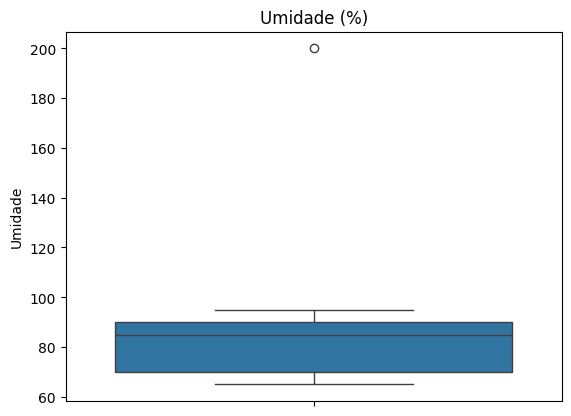

In [87]:
sns.boxplot(join).set_title('Umidade (%)')

Text(0.5, 1.0, 'Umidade (%)')

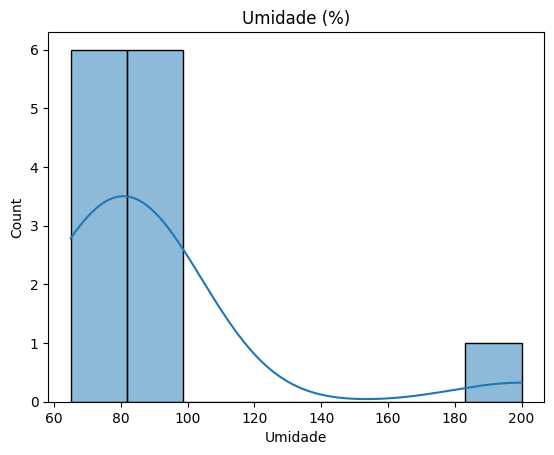

In [88]:
sns.histplot(join, kde=True).set_title('Umidade (%)')

Os gráficos apresentam apenas um valor distorcendo o conjunto de dados.

In [89]:
mean = round(sts.mean(join), 2)
f"Media da Umidade: {mean} %."

'Media da Umidade: nan %.'

Não foi possível encontrar a média dos valores.

In [90]:
median = round(sts.median(join), 2)
f"Mediana da Umidade: {median} %."

'Mediana da Umidade: 85.5 %.'

Mediana condizente com o contexto.

In [91]:
dataset["Umidade"].isnull().sum()

np.int64(1)

Um valor nulo foi encontrado.

##### Vento

Este dataset condiz com a presença de ventos e ventânias nos dias registrados.

In [92]:
join = dataset.groupby(["Vento"]).size()
join

Vento
FALSO         7
VERDADEIRO    6
dtype: int64

<Axes: ylabel='Vento'>

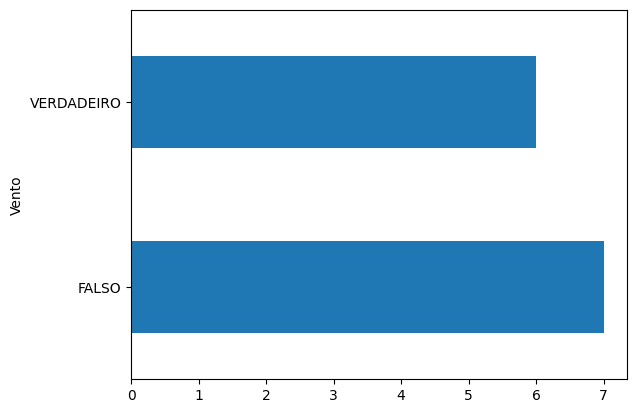

In [93]:
join.plot.barh(x="Vento", y="Frequencia")

In [94]:
mode = dataset["Vento"].mode()[0]
f"Moda da presença de ventos: {mode}"

'Moda da presença de ventos: FALSO'

Percebe-se que a moda é "FALSO".

In [95]:
dataset["Vento"].isnull().sum()

np.int64(1)

Um valor nulo foi encontrado.

##### Jogar

Este dataset condiz com a decisão dos times de jogar ou não nos dias registrados.

In [96]:
join = dataset.groupby("Jogar").size()
join

Jogar
nao    5
sim    9
dtype: int64

<Axes: ylabel='Jogar'>

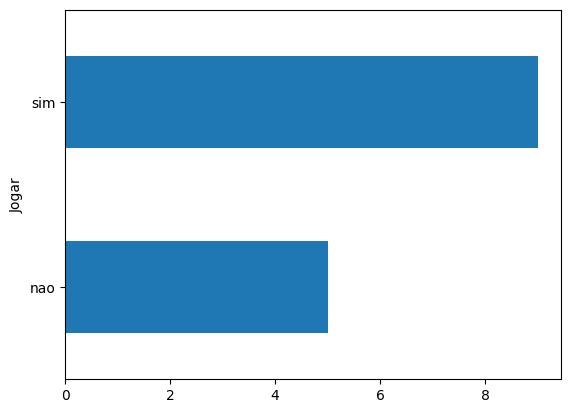

In [97]:
join.plot.barh(x="Jogar", y="Frequencia")

In [98]:
mode = dataset["Jogar"].mode()[0]
f"Moda da presença de jogos: {mode}"

'Moda da presença de jogos: sim'

Percebe-se que a moda é "sim".

In [99]:
join.isnull().sum()

np.int64(0)

Nenhum valor nulo foi encontrado.

#### Limpeza e tratamento de dados

##### Aparência

Tratamento do valor inválido:
- Por se tratar de um tipo de dado categórico, recomenda-se que este deve ser substituído pela moda. Ou seja, pelo valor mais recorrente.

In [100]:
mode = dataset['Aparencia'].mode()[0]
mode

'chuva'

Neste caso, a moda é 'chuva'.

In [101]:
# substituindo o valor inválido pela moda
dataset.loc[dataset["Aparencia"] == "menos", "Aparencia"] = mode

In [102]:
join = dataset.groupby("Aparencia").size()
join

Aparencia
chuva      6
nublado    3
sol        5
dtype: int64

<Axes: ylabel='Aparencia'>

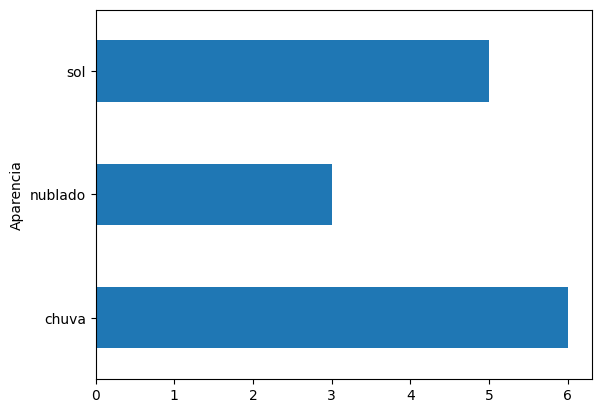

In [103]:
join.plot.barh(x="Aparencia", y="Frequencia")

O valor inválido foi reajustado.

##### Temperatura

Tratamento do valor outlier:
- Realizar a varredura por mais outliers. Através de um recorte utilizando a média - visto que o desvio padrão está muito distoante.
- Por se tratar de um tipo de dado quantitativo, recomenda-se que este deve ser substituído pela mediana. Ou seja, pela temperatura central dos dados.
- Recalcular métricas e avaliar tratamento.

In [104]:
join = dataset["Temperatura"].astype(float)
join.describe()

count      14.000000
mean      155.571429
std       306.433759
min        64.000000
25%        69.250000
50%        73.500000
75%        80.750000
max      1220.000000
Name: Temperatura, dtype: float64

In [105]:
mean = sts.mean(dataset["Temperatura"])
mean

155.57142857142858

Neste caso, a média é de 155.57 °F.

In [106]:
outlier = (dataset["Temperatura"] < -mean) | (dataset["Temperatura"] > mean)
dataset.loc[outlier]

,Aparencia,Temperatura,Umidade,Vento,Jogar
7,sol,1220,95.0,FALSO,nao


Portanto, foi encontrado apenas um outlier. Que será substituido pela mediana.

In [107]:
median = sts.median(dataset["Temperatura"])
median

73.5

A mediana é de 73.5 °F.

In [108]:
dataset.loc[(dataset["Temperatura"] < -mean) | (dataset["Temperatura"] > mean), 'Temperatura'] = median
dataset.loc[(dataset["Temperatura"] < -mean) | (dataset["Temperatura"] > mean)]

C:\Users\Nattam\AppData\Local\Temp\ipykernel_42304\2037498965.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '73.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataset.loc[(dataset["Temperatura"] < -mean) | (dataset["Temperatura"] > mean), 'Temperatura'] = median


,Aparencia,Temperatura,Umidade,Vento,Jogar


In [109]:
join = dataset["Temperatura"]
join.describe()

count    14.000000
mean     73.678571
std       6.556286
min      64.000000
25%      69.250000
50%      72.750000
75%      78.750000
max      85.000000
Name: Temperatura, dtype: float64

In [110]:
mean = round(sts.mean(join), 2)
f"Media Corrigida da Temperatura: {mean} °F."

'Media Corrigida da Temperatura: 73.68 °F.'

In [111]:
median = round(sts.median(join), 2)
f"Mediana Corrigida da Temperatura: {median} °F."

'Mediana Corrigida da Temperatura: 72.75 °F.'

In [112]:
std = round(sts.stdev(join), 2)
f"Desvio Padrão Corrigido da Temperatura: {std} °F."

'Desvio Padrão Corrigido da Temperatura: 6.56 °F.'

É possível saber que o outlier foi tratado e as demais métricas reajustadas.

Text(0.5, 1.0, 'Temperatura (°F)')

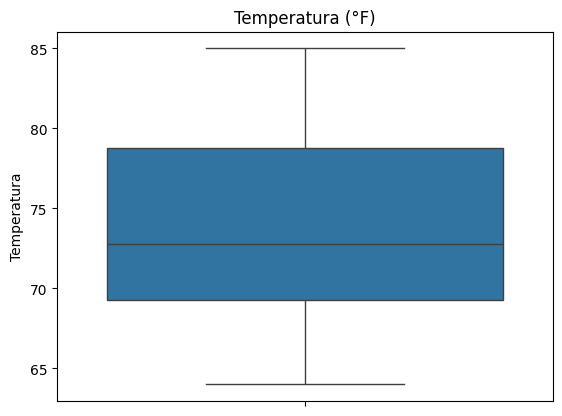

In [113]:
sns.boxplot(join).set_title('Temperatura (°F)')

Text(0.5, 1.0, 'Temperatura (°F)')

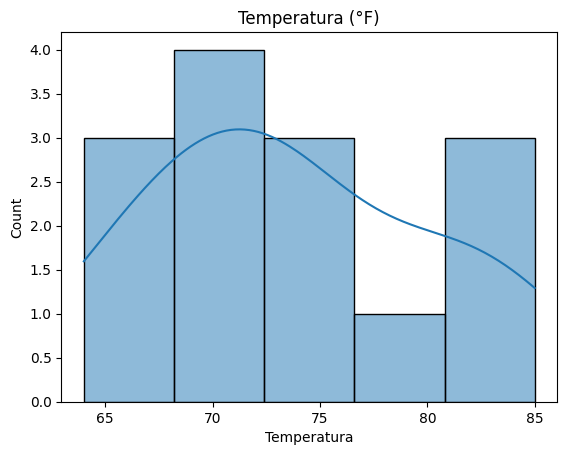

In [114]:
sns.histplot(join, kde=True).set_title('Temperatura (°F)')

In [115]:
join.describe()

count    14.000000
mean     73.678571
std       6.556286
min      64.000000
25%      69.250000
50%      72.750000
75%      78.750000
max      85.000000
Name: Temperatura, dtype: float64

Agora, é possível identificar uma concentração de temperatura por volta dos 72 °F.

##### Umidade

Tratamento dos valores inválidos:
- Tratar o dado identificado como nulo.
- Realizar a varredura por mais outliers. Entende-se que, no contexto de umidade do ambiente, não serão considerados valores maiores do que 100 % e nem menores do que 0 %.
- Por se tratar de um tipo de dado quantitativo, recomenda-se que este deve ser substituído pela mediana. Ou seja, pela temperatura central dos dados.
- Recalcular métricas e avaliar tratamento.

In [116]:
join = dataset["Umidade"]
join.describe()

count     13.000000
mean      89.769231
std       34.540203
min       65.000000
25%       70.000000
50%       85.000000
75%       90.000000
max      200.000000
Name: Umidade, dtype: float64

In [117]:
dataset["Umidade"].isnull().sum()

np.int64(1)

O valor nulo será tratado primeiro.

In [118]:
median = sts.median(dataset["Umidade"])
median

85.5

In [119]:
dataset["Umidade"].fillna(median, inplace=True)
dataset["Umidade"].isnull().sum()

np.int64(0)

Percebe-se que o valor nulo não está mais presente. Agora, ao outlier.

In [120]:
outlier = (dataset["Umidade"] < 0) | (dataset["Umidade"] > 100)
dataset.loc[outlier]

,Aparencia,Temperatura,Umidade,Vento,Jogar
9,chuva,75.0,200.0,NaN,sim


Portanto, foi encontrado apenas um outlier. Que será substituido pela mediana.

In [121]:
dataset.loc[(dataset["Umidade"] < 0) | (dataset["Umidade"] > 100), 'Umidade'] = median
dataset.loc[(dataset["Umidade"] < 0) | (dataset["Umidade"] > 100)]

,Aparencia,Temperatura,Umidade,Vento,Jogar


In [122]:
join = dataset["Umidade"]
join.describe()

count    14.000000
mean     81.285714
std       9.585073
min      65.000000
25%      71.250000
50%      85.250000
75%      89.000000
max      95.000000
Name: Umidade, dtype: float64

In [123]:
std = round(sts.stdev(join), 2)
std

9.59

In [124]:
mean = round(sts.mean(join), 2)
mean

81.29

O outlier não está mais presente e os valores foram reajustados:
- Desvio-padrão: 9.58 %
- Média: 81.28 %

Text(0.5, 1.0, 'Umidade')

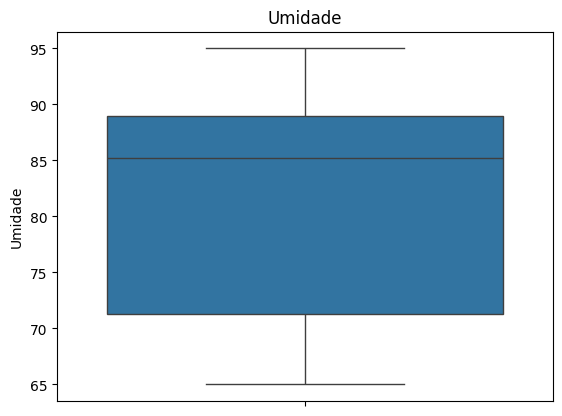

In [125]:
sns.boxplot(join).set_title('Umidade')

Text(0.5, 1.0, 'Umidade')

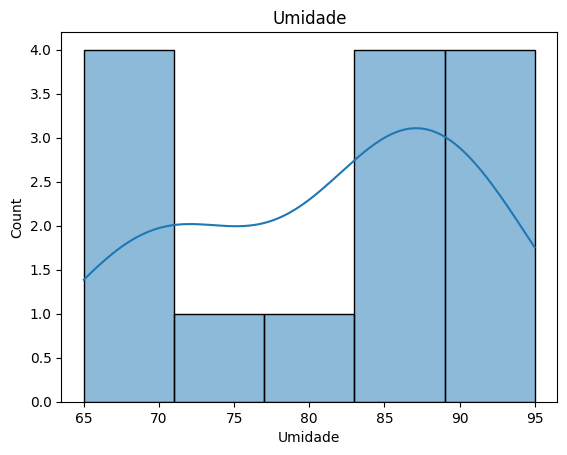

In [126]:
sns.histplot(join, kde=True).set_title('Umidade')

In [127]:
join.describe()

count    14.000000
mean     81.285714
std       9.585073
min      65.000000
25%      71.250000
50%      85.250000
75%      89.000000
max      95.000000
Name: Umidade, dtype: float64

É possível identificar uma concentração nos valores  até 70 % e acima de 85 %.

#### Vento

Tratamento dos valores inválidos:
- Tratar o dado identificado como nulo.
- Por se tratar de um tipo de dado qualitativo, recomenda-se que este deve ser substituído pela moda. Ou seja, pela maior ocorrência dos dados.
- Recalcular métricas e avaliar tratamento.

In [128]:
join = dataset.groupby("Vento").size()
join

Vento
FALSO         7
VERDADEIRO    6
dtype: int64

In [129]:
dataset["Vento"].isnull().sum()

np.int64(1)

In [130]:
mode = dataset["Vento"].mode()[0]
mode

'FALSO'

Após identificar a moda, substituir nos valores nulos.

In [131]:
dataset.fillna({"Vento": mode}, inplace=True)
dataset["Vento"].isnull().sum()

np.int64(0)

O valor nulo não está mais presente.

In [132]:
join = dataset.groupby("Vento").size()
join

Vento
FALSO         8
VERDADEIRO    6
dtype: int64

<Axes: ylabel='Vento'>

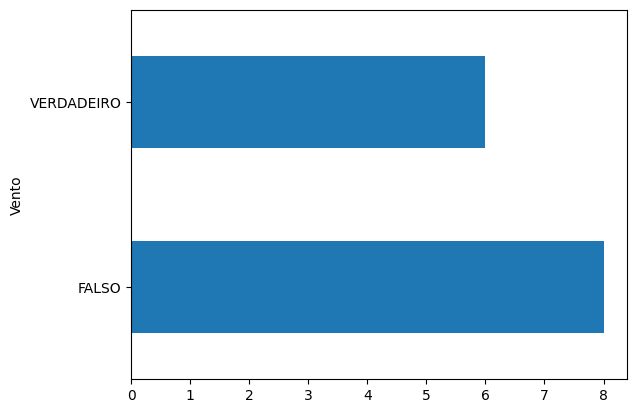

In [133]:
join.plot.barh(x="Vento", y="Frequencia")

Percebe-se uma predominância de dias sem ventos.

#### Conclusões

Aparência:
- A maior parte dos dias foi identificada chuva. Seguido de sol e nublado respectivamente.

Temperatura:
- Identificou-se uma predominância de 72 °F durante os dias.
- Desvio-padrão de 6.56 °F.
- Média de 73.68 °F.
- Mediana de 72.75 °F.

Umidade:
- Identificou-se uma predominância de 85 % durante os dias.
- Desvio-padrão: 9.58 %
- Média: 81.28 %
- Mediana de 85.75 %.

Vento:
- A maior parte dos dias foi identificada sem ventos.

Jogar:
- A maior parte dos dias decidiram por jogar.